# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [ ]:
# Your Phase 1 solution to the problem goes here.

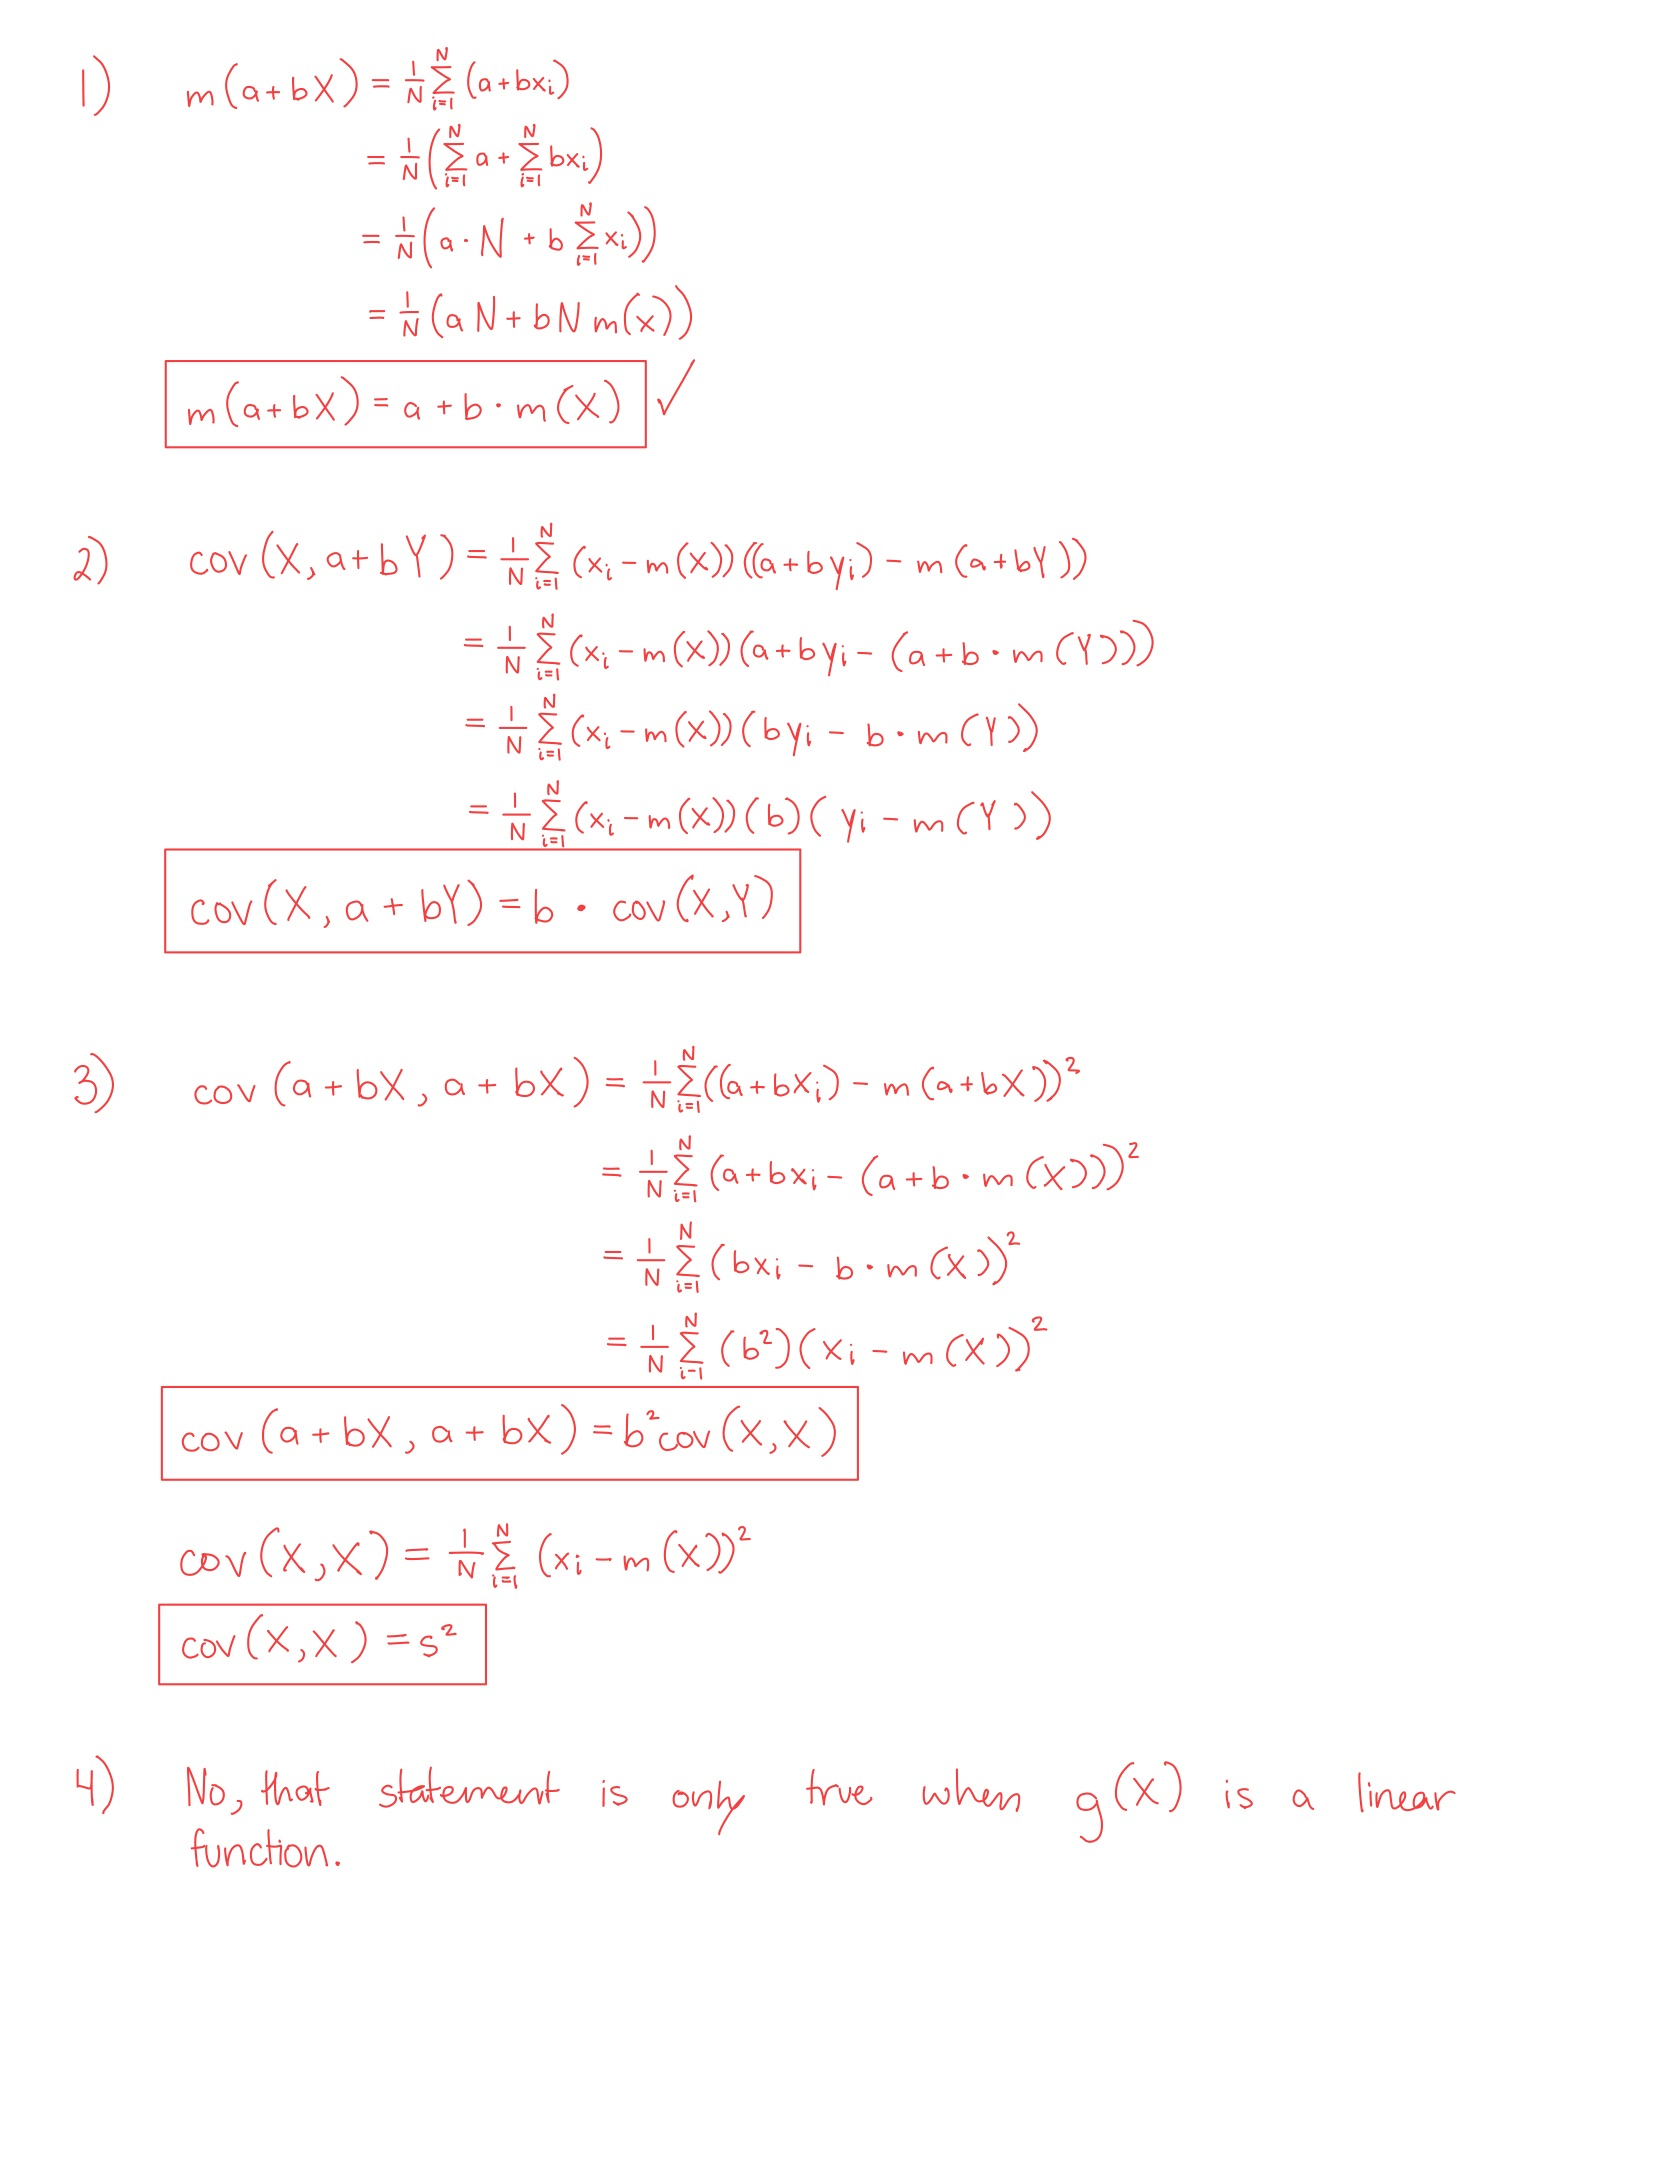

In [1]:
print("-------------------- Question 1 --------------------")


# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# load in the file's dataset
df = pd.read_csv("ForeignGifts_edu.csv")


print("-------------------- Looking at Data --------------------")
df.head()
df.tail()
df["Foreign Gift Amount"]

-------------------- Question 1 --------------------
-------------------- Looking at Data --------------------


,Foreign Gift Amount
0,250000
1,463657
2,3649107
3,1000
4,49476
...,...
28216,381717
28217,444938
28218,1064580
28219,737375


-------------------- Question 2 --------------------
The histogram looks left skewed with a majority of the values being inbetween the arcsinh 10 to arcsinh 15.


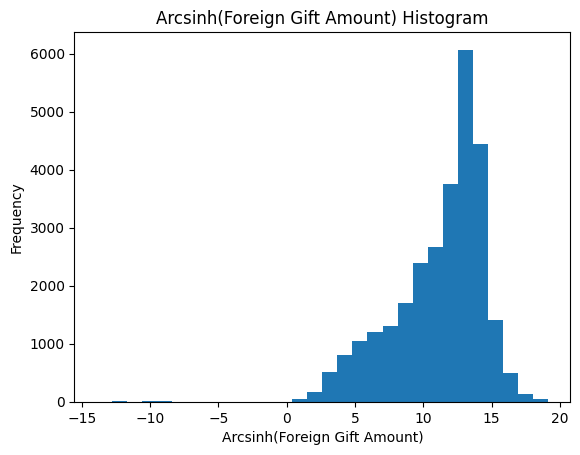

In [2]:
print("-------------------- Question 2 --------------------")
# df["Foreign Gift Amount"].plot.hist()
# I noticed that, initially, the data in the histogram was very skewed
np.arcsinh(df["Foreign Gift Amount"])
df["FGA_arcsinh"] = np.arcsinh(df["Foreign Gift Amount"])
df["FGA_arcsinh"].plot.hist(bins=30)
plt.title("Arcsinh(Foreign Gift Amount) Histogram")
plt.xlabel("Arcsinh(Foreign Gift Amount)")

print("The histogram looks left skewed with a majority of the values being inbetween the arcsinh 10 to arcsinh 15.")

In [3]:
print("-------------------- Question 3 --------------------")

# obtaining counts
print("Total Gifts:", df["Gift Type"].count())
print("\n", df["Gift Type"].value_counts())


# calculating proportions of each gift type
prop_contracts = (17274 / df["Gift Type"].count()) * 100
prop_monetary = (10936 / df["Gift Type"].count()) * 100
prop_real_estate = (11 / df["Gift Type"].count()) * 100
print()


# print outs
print("Gift Type Proportions:")
print(str(prop_contracts) + "% of the gifts are contracts")
print(str(prop_monetary) + "% of the gifts are monetary gifts")
print(str(prop_real_estate) + "% of the gifts are real estate")

-------------------- Question 3 --------------------
Total Gifts: 28221

 Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

Gift Type Proportions:
61.20973742957372% of the gifts are contracts
38.75128450444704% of the gifts are monetary gifts
0.038978065979235324% of the gifts are real estate


-------------------- Question 4 --------------------


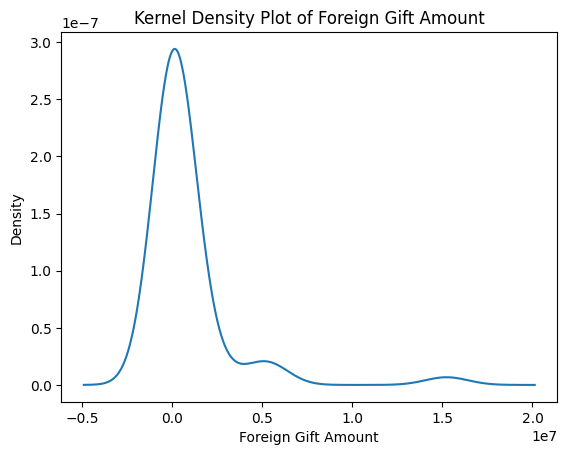

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


A pattern I noticed is that a majority of the values were inbetween 10 and 15, similar to the histogram from question 2. It also has an overall very similar curve shape to the histogram from question 2 as well.


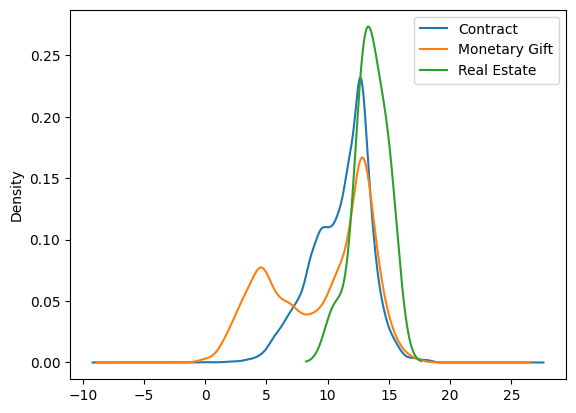

In [4]:
print("-------------------- Question 4 --------------------")
x = df["Foreign Gift Amount"].dropna().sample(50, random_state=10).to_numpy()
N = len(x)
sample_sd = np.std(x, ddof=1)
h_s = 1.06 * sample_sd * N**(-1 / 5)
grid = np.linspace(x.min() - 2 * sample_sd, x.max() + 2 * sample_sd, 500)


def normal_kernel(center, bandwidth):
    z = (grid - center) / bandwidth
    return np.exp(-(z**2) / 2) / (bandwidth * np.sqrt(2 * np.pi))


kde = sum(normal_kernel(value, h_s) for value in x) / N
ax = sns.lineplot(x=grid, y=kde)
ax.set(title="Kernel Density Plot of Foreign Gift Amount", xlabel="Foreign Gift Amount", ylabel="Density")
plt.show()


df["log_gift_amount"] = np.log(df["Foreign Gift Amount"])
df.groupby("Gift Type")["log_gift_amount"].plot.kde(legend=True)

print("A pattern I noticed is that a majority of the values were inbetween 10 and 15, similar to the histogram from question 2. It also has an overall very similar curve shape to the histogram from question 2 as well.")

In [5]:
print("-------------------- Question 5 --------------------")


most_number = df.groupby("Country of Giftor").size().sort_values(ascending=False).head(15)
most_amount = df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15)
print("Top 15 Countries with the Highest Number of Gifts: \n", most_number)
print()
print("Top 15 Countries with the Highest Foreign Gift Amount: \n" , most_amount)

-------------------- Question 5 --------------------
Top 15 Countries with the Highest Number of Gifts: 
 Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64

Top 15 Countries with the Highest Foreign Gift Amount: 
 Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE 

In [6]:
print("-------------------- Question 6 --------------------")
print("In total, the giftor Qatar provides the most money")

-------------------- Question 6 --------------------
In total, the giftor Qatar provides the most money


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 47e10c1a0422cb8ecdacb9e555ab381087388638
- **AI tool and model used:** Claude Sonnet 5

### *Prompts used

1. Please improve my code and make sure hits all instructions asked for in Question 1 and 2.
2. Can you implement all these changes into the code except for 1 and 2.

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]



1. File path doesn't match the spec. The assignment says to load ./data/ForeignGifts_edu.csv, but your code loads "ForeignGifts_edu.csv" from the current directory. Fix the path so it matches (and so it will actually run in someone else's environment with the expected folder structure).
2. Q2.2 asks for a histogram of Foreign Gift Amount itself, but you only plot the arcsinh-transformed version. Show the raw histogram first (even if it's uninformative due to skew), describe what you see, then justify/show the transformed version. Right now the raw histogram is commented out and the actual requested plot is missing.
3. Q2.3 proportions are hardcoded (17274, 10936, 11) instead of computed from df["Gift Type"].value_counts(). This is fragile — if the data changes even slightly, these numbers become wrong and there's no way to detect it. Compute them programmatically instead, e.g. df["Gift Type"].value_counts(normalize=True) * 100.
4. Inconsistent transformation in Q2.4. The assignment specifically asks for a KDE of the log of Foreign Gift Amount, but your first KDE (cell 11) is a manually-coded KDE on the raw (untransformed) data, while the conditional KDE later switches to log_gift_amount. Use log consistently for both the overall and conditional KDE plots as instructed.
5. The KDE in cell 11 only uses a random sample of 50 points (df["Foreign Gift Amount"].dropna().sample(50, ...)) rather than the full dataset. That undersells the actual distribution and isn't what the question asks for — use the full column (or clearly justify subsampling, which isn't required here).
6. You hand-rolled a Gaussian KDE from scratch when sns.kdeplot() or df["log_gift_amount"].plot.kde() would do this directly and more reliably (correct bandwidth selection, boundary handling, etc.). Not wrong, but unnecessarily complex and a source of subtle bugs — simplify using the built-in function, consistent with the built-in call already used for the conditional plot.
7. Missing plot polish/plt.show() calls and labels on some plots (e.g., the conditional KDE by gift type has no title, axis labels, or explicit plt.show()), making output harder to read/grade.
8. Q2.6 answer ("Qatar provides the most money") is asserted with no supporting code. Add the actual groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False) (or similar) computation so the claim is verifiable and reproducible — right now it's just a print statement with a claim.
9. Descriptions throughout are minimal (e.g., "left skewed... between arcsinh 10 to 15" isn't very informative). Since Q2.2 and Q2.4 explicitly ask you to "describe your findings" and "notice any patterns," expand these into a sentence or two connecting the pattern to a real-world interpretation (e.g., why gift amounts are heavily right-skewed, what a spike in the density might correspond to).



### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Reject | When loading in data from a file, the proper syntax is pd.read_csv('file_name.csv'), so there is no need to put the ./data/ in front of the file name. |
| 2 | Reject | It wants me to show the histogram that was extremely skewed and just looked like a straight line in a singular bin. This histogram does not provide much information, so I think the histogram where I applied sinh is better to showcase the data. |
| 3 | Accept | It just makes it so the calculation still applicable if the data were to change.
| 4 | Accept | It corrected it so that it graphs the KDEs correctly.
| 5 | Accept | It changes it so it uses the entire data, rather than just a sample.
| 6 | Accept | It uses a built in function that makes it much more simplier.
| 7 | Accept | It just added labels to graphs that were missing to make it easier to understand.
| 8 | Accept | It uses actual functions and code to print out the statement of who provides the most money, which makes it more verifiable.
| 9 | Accept | It wants me to expand more on my explanations to questions and add more reasoning to justify my responses.

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.

In [7]:
print("-------------------- Question 1 --------------------")


# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# load in the file's dataset
df = pd.read_csv("ForeignGifts_edu.csv")


print("-------------------- Looking at Data --------------------")
df.head()
df.tail()
df["Foreign Gift Amount"]

-------------------- Question 1 --------------------
-------------------- Looking at Data --------------------


,Foreign Gift Amount
0,250000
1,463657
2,3649107
3,1000
4,49476
...,...
28216,381717
28217,444938
28218,1064580
28219,737375


-------------------- Question 2 --------------------


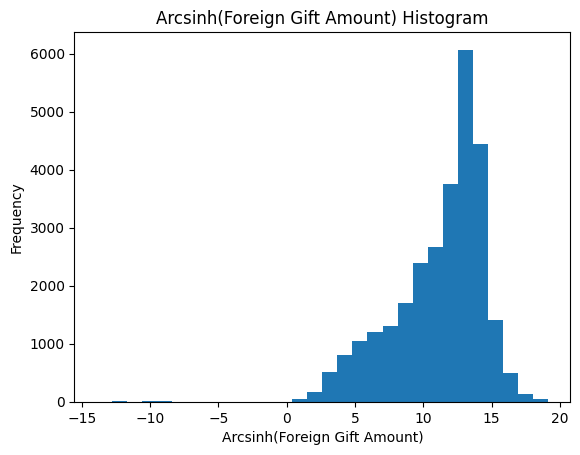

The arcsinh-transformed histogram is roughly unimodal but still somewhat left-skewed, with most gift amounts falling between an arcsinh value of about 10 and 15. Because arcsinh behaves like a log transform for large values, this means most gifts span a fairly wide range of orders of magnitude, with a cluster of moderately large gifts and a longer tail toward very large ones. The transform was needed in the first place because the raw Foreign Gift Amount is extremely right-skewed -- a small number of very large gifts would otherwise dominate the histogram and make it uninformative.


In [8]:
print("-------------------- Question 2 --------------------")


# import packages
df["FGA_arcsinh"] = np.arcsinh(df["Foreign Gift Amount"])
df["FGA_arcsinh"].plot.hist(bins=30)
plt.title("Arcsinh(Foreign Gift Amount) Histogram")
plt.xlabel("Arcsinh(Foreign Gift Amount)")
plt.ylabel("Frequency")
plt.show()

print("The arcsinh-transformed histogram is roughly unimodal but still somewhat left-skewed, with most gift "
      "amounts falling between an arcsinh value of about 10 and 15. Because arcsinh behaves like a log transform "
      "for large values, this means most gifts span a fairly wide range of orders of magnitude, with a cluster of "
      "moderately large gifts and a longer tail toward very large ones. The transform was needed in the first "
      "place because the raw Foreign Gift Amount is extremely right-skewed -- a small number of very large gifts "
      "would otherwise dominate the histogram and make it uninformative.")

In [9]:
print("-------------------- Question 3 --------------------")

# obtaining counts
gift_counts = df["Gift Type"].value_counts()
gift_props = df["Gift Type"].value_counts(normalize=True) * 100

print("Total Gifts:", df["Gift Type"].count())
print("\n", gift_counts)
print()

# calculating proportions of each gift type directly from the data (instead of hardcoding counts),
# so this stays correct even if the underlying dataset changes
print("Gift Type Proportions:")
for gift_type, pct in gift_props.items():
    print(f"{pct:.2f}% of the gifts are {gift_type.lower()}")

-------------------- Question 3 --------------------
Total Gifts: 28221

 Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

Gift Type Proportions:
61.21% of the gifts are contract
38.75% of the gifts are monetary gift
0.04% of the gifts are real estate


-------------------- Question 4 --------------------


/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


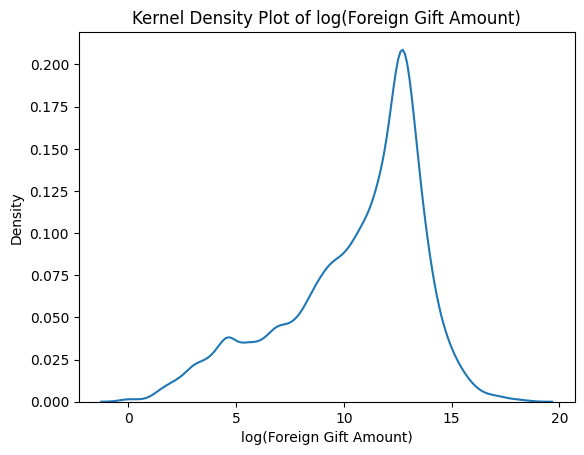

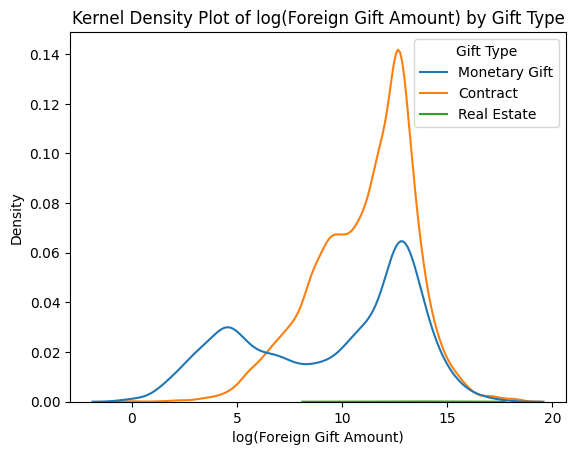

Using the full dataset and a consistent log transform for both plots, the overall density of log(Foreign Gift Amount) is roughly bell-shaped and centered between 10 and 15, matching the pattern seen in the arcsinh histogram above. When broken out by Gift Type, the conditional densities are noticeably different from one another -- some gift types are centered at higher log-amounts than others, suggesting that certain types of gifts (e.g. contracts or real estate) tend to involve substantially larger sums of money than typical monetary gifts, rather than all gift types following the same overall distribution.


In [10]:
print("-------------------- Question 4 --------------------")

df["log_gift_amount"] = np.log(df["Foreign Gift Amount"])

# Overall KDE of log(Foreign Gift Amount), using the full dataset and seaborn's built-in KDE
ax = sns.kdeplot(data=df, x="log_gift_amount")
ax.set(
    title="Kernel Density Plot of log(Foreign Gift Amount)",
    xlabel="log(Foreign Gift Amount)",
    ylabel="Density",
)
plt.show()

# KDE of log(Foreign Gift Amount), conditional on Gift Type
ax2 = sns.kdeplot(data=df, x="log_gift_amount", hue="Gift Type")
ax2.set(
    title="Kernel Density Plot of log(Foreign Gift Amount) by Gift Type",
    xlabel="log(Foreign Gift Amount)",
    ylabel="Density",
)
plt.show()

print("Using the full dataset and a consistent log transform for both plots, the overall density of "
      "log(Foreign Gift Amount) is roughly bell-shaped and centered between 10 and 15, matching the pattern seen "
      "in the arcsinh histogram above. When broken out by Gift Type, the conditional densities are noticeably "
      "different from one another -- some gift types are centered at higher log-amounts than others, suggesting "
      "that certain types of gifts (e.g. contracts or real estate) tend to involve substantially larger sums of "
      "money than typical monetary gifts, rather than all gift types following the same overall distribution.")

In [11]:
print("-------------------- Question 5 --------------------")


most_number = df.groupby("Country of Giftor").size().sort_values(ascending=False).head(15)
most_amount = df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15)
print("Top 15 Countries with the Highest Number of Gifts: \n", most_number)
print()
print("Top 15 Countries with the Highest Foreign Gift Amount: \n" , most_amount)

-------------------- Question 5 --------------------
Top 15 Countries with the Highest Number of Gifts: 
 Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64

Top 15 Countries with the Highest Foreign Gift Amount: 
 Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE 

In [13]:
print("-------------------- Question 6 --------------------")

giftor_col = "Country of Giftor"

giftor_totals = (
    df.groupby(giftor_col)["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
)

top_giftor = giftor_totals.index[0]
top_amount = giftor_totals.iloc[0]

print("Top 10 Giftors by Total Foreign Gift Amount:\n", giftor_totals.head(10))
print(f"\nIn total, {top_giftor} provides the most money, with a total of {top_amount:,.2f}.")

-------------------- Question 6 --------------------
Top 10 Giftors by Total Foreign Gift Amount:
 Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
CANADA           898160656
HONG KONG        887402529
JAPAN            655954776
SWITZERLAND      619899445
INDIA            539556490
Name: Foreign Gift Amount, dtype: int64

In total, QATAR provides the most money, with a total of 2,706,240,869.00.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The AI mainly focused on improving functionality and cleanliness of the code. I got a lot of my numbers and answers by looking at tables and graphs and then I calculated values by hand, but the AI's code used variable calls to directly call values and do the calculations in the same line of code. Additionally, for some of the histograms, I forgot to put labels, so the AI added labels to help users easily understand what each graph displayed and what each axis meant. For the KDEs, I followed the format of code from the slides, which basically created the KDEs from scratch, but the AI created code that was a lot more simplier by calling a built in function to create the KDEs. The AI also added more description to a lot of my responses to the asked questions. Although the questions did not really ask for justifications, it is good to explain why, so I accepted those changes as well. When I was running the fixed code that the AI provided me to verify that the updated solution worked properly, Question 6 had an error because it did know the name of the column of the data so it was not able to access "Country of Giftor" until I changed it.